# Background Cosmology: $H(z)$ and $n_e(z)$

Plots of the Hubble rate and free electron density as a function of redshift,
using the cosmological parameters from spectroxide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spectroxide.style import apply_style
from spectroxide.greens import (
    _cosmo_hubble, _cosmo_n_h, _cosmo_n_e,
    _cosmo_omega_gamma, _cosmo_omega_rel, _cosmo_h0,
    _saha_hydrogen, _helium_electron_fraction,
    _C_LIGHT, _K_BOLTZMANN, _HBAR, _G_NEWTON, _M_PROTON, _SIGMA_THOMSON,
    DEFAULT_COSMO, PLANCK2015_COSMO,
)
from spectroxide import ionization_fraction

apply_style()

## Ionization fraction $X_e(z)$

The full recombination calculation is implemented in `src/recombination.rs`
and ported to Python in `spectroxide.greens.ionization_fraction()`:
- **He II recombination** ($z \sim 6000$): Saha equilibrium at 54.4 eV
- **He I recombination** ($z \sim 2000$): Saha equilibrium at 24.6 eV
- **Hydrogen recombination** ($z \sim 1500$–$800$): Saha at high $z$, then
  Peebles three-level atom ODE with fudge factor $F = 1.125$
  (Chluba & Thomas 2011)
- **Freeze-out** ($z < 200$): residual $X_e \sim 2 \times 10^{-4}$

In [2]:
cosmo = DEFAULT_COSMO

# Quick sanity check
z_test = np.array([1e6, 1e4, 1500, 1100, 800, 200, 50])
x_test = ionization_fraction(z_test, cosmo)
print(f"{'z':>10s}  {'X_e':>12s}")
print("-" * 25)
for zi, xi in zip(z_test, x_test):
    print(f"{zi:10.0f}  {xi:12.6f}")

         z           X_e
-------------------------
   1000000      1.157895
     10000      1.157895
      1500      0.954652
      1100      0.142078
       800      0.003405
       200      0.000332
        50      0.000253


## Hubble Rate $H(z)$

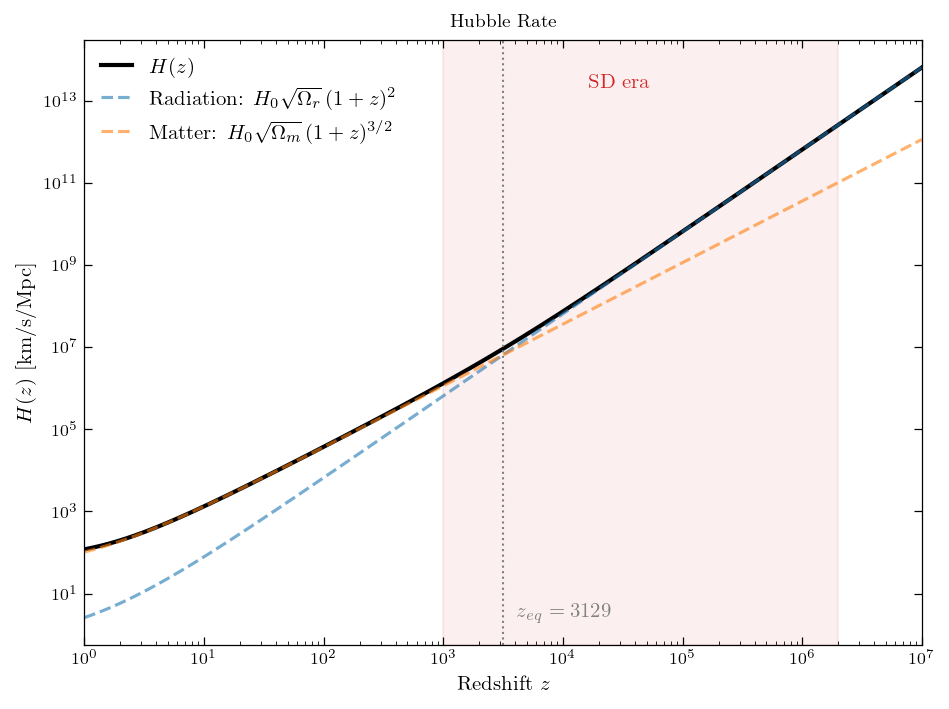

H(0) = 71.0 km/s/Mpc
z_eq = 3129
H(z_eq) = 8.97e+06 km/s/Mpc


In [3]:
cosmo = DEFAULT_COSMO
z = np.logspace(0, 7, 1000)

H_z = np.array([_cosmo_hubble(zi, cosmo) for zi in z])
H_km_s_Mpc = H_z / 3.240_779_29e-20  # convert 1/s to km/s/Mpc

# Reference scalings
H0 = 100 * cosmo["h"]  # km/s/Mpc
omega_m = cosmo["omega_m"]
omega_rel = _cosmo_omega_rel(cosmo)
omega_lam = 1 - omega_m - omega_rel

# Matter-radiation equality
z_eq = omega_m / omega_rel - 1

fig, ax = plt.subplots()
ax.loglog(z, H_km_s_Mpc, 'k-', lw=2, label=r'$H(z)$')

# Asymptotic scalings
H_rad = H0 * np.sqrt(omega_rel) * (1 + z)**2
H_mat = H0 * np.sqrt(omega_m) * (1 + z)**1.5
ax.loglog(z, H_rad, '--', color='C0', alpha=0.6, lw=1.5,
          label=r'Radiation: $H_0\sqrt{\Omega_r}\,(1+z)^2$')
ax.loglog(z, H_mat, '--', color='C1', alpha=0.6, lw=1.5,
          label=r'Matter: $H_0\sqrt{\Omega_m}\,(1+z)^{3/2}$')

ax.axvline(z_eq, color='gray', ls=':', lw=1)
ax.text(z_eq * 1.3, ax.get_ylim()[0] * 5, f'$z_{{eq}} = {z_eq:.0f}$',
        fontsize=10, color='gray')

# Mark spectral distortion era
ax.axvspan(1e3, 2e6, alpha=0.07, color='C3')
ax.text(3e4, H_km_s_Mpc.max() * 0.3, 'SD era', fontsize=10, color='C3', ha='center')

ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$H(z)$ [km/s/Mpc]')
ax.set_title('Hubble Rate')
ax.set_xlim(1, 1e7)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f"H(0) = {_cosmo_hubble(0, cosmo)/3.24e-20:.1f} km/s/Mpc")
print(f"z_eq = {z_eq:.0f}")
print(f"H(z_eq) = {_cosmo_hubble(z_eq, cosmo)/3.24e-20:.2e} km/s/Mpc")

## Free Electron Density $n_e(z)$

In [4]:
z = np.logspace(1, 7, 2000)

# Compute ionization fraction (production Peebles TLA + Saha helium)
X_e = ionization_fraction(z, cosmo)

# Hydrogen number density
n_H = np.array([_cosmo_n_h(zi, cosmo) for zi in z])

# Free electron density
n_e = X_e * n_H

# For comparison: fully ionized (no recombination)
f_he = cosmo["y_p"] / (4 * (1 - cosmo["y_p"]))
n_e_full = (1 + f_he) * n_H

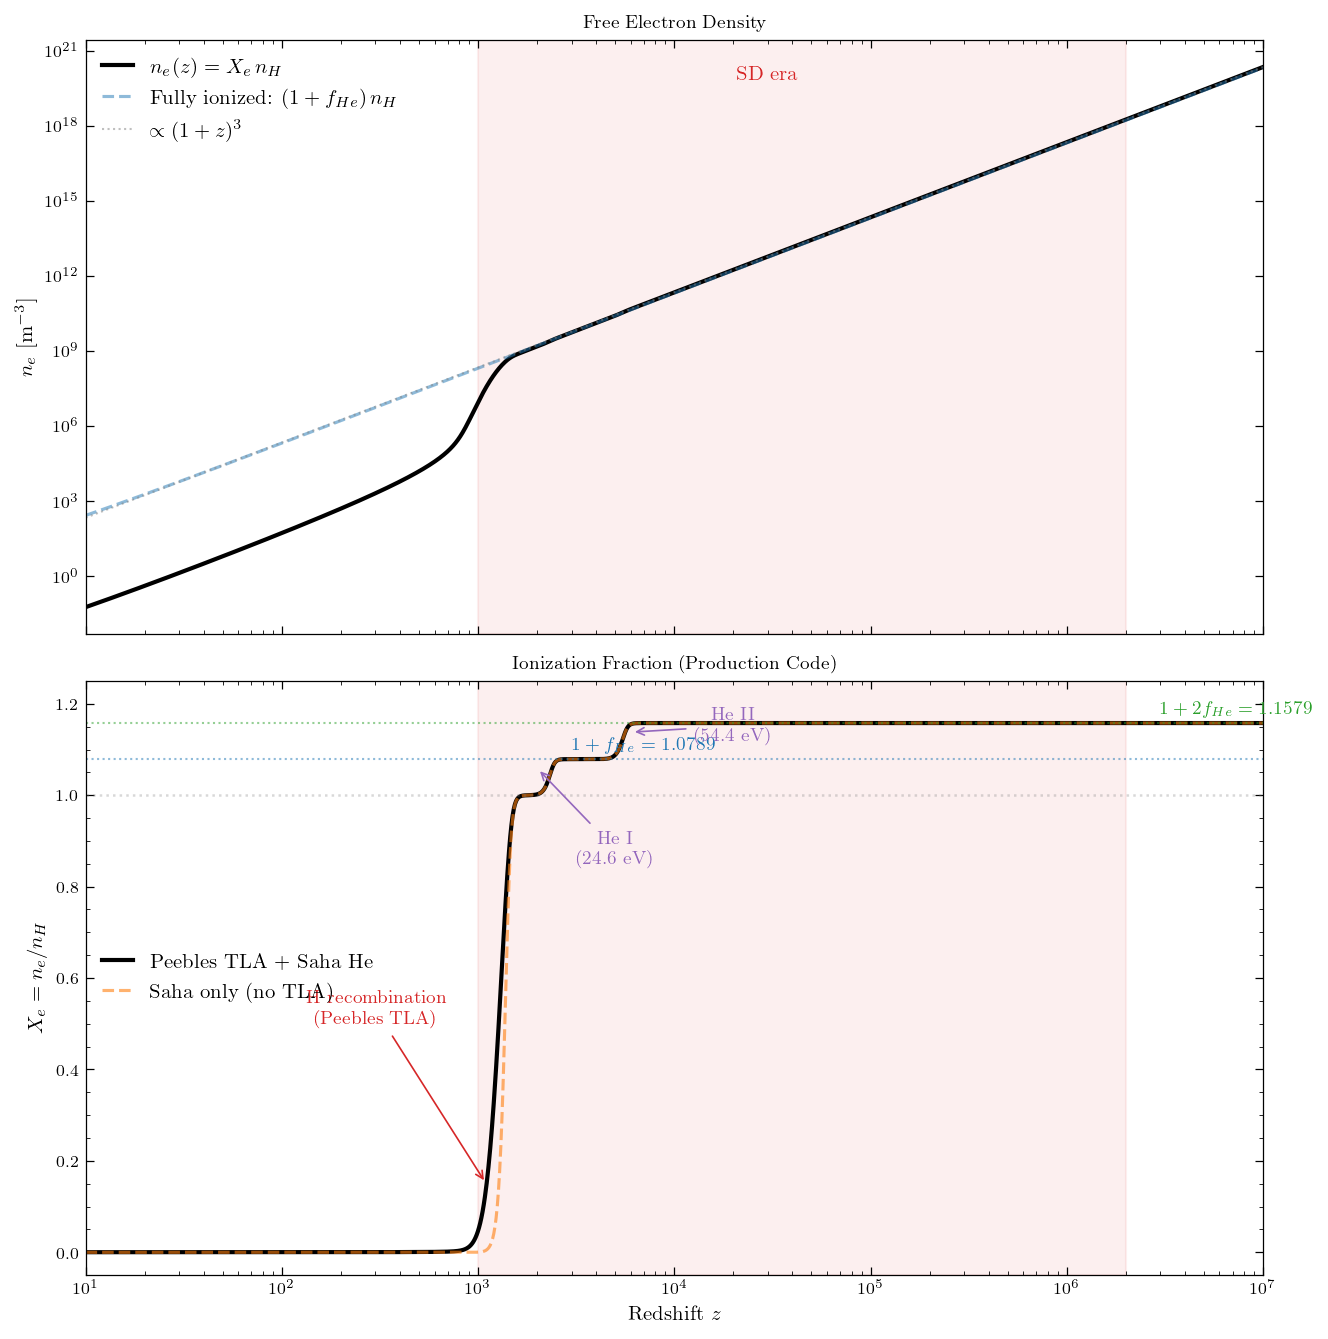

X_e(z=1e6) = 1.1579  (expect 1+2*f_He = 1.1579)
X_e(z=3000) = 1.0789  (He I recombining)
X_e(z=1100) = 0.1421  (mid-H recombination)
X_e(z=800) = 0.003405  (mostly recombined)
X_e(z=200) = 0.000332  (freeze-out)


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# -- Top panel: n_e(z) --
ax1.loglog(z, n_e, 'k-', lw=2, label=r'$n_e(z) = X_e \, n_H$')
ax1.loglog(z, n_e_full, '--', color='C0', alpha=0.5, lw=1.5,
           label=r'Fully ionized: $(1+f_{He})\,n_H$')

# (1+z)^3 reference
z_ref = 1e6
n_ref = n_e[np.argmin(np.abs(z - z_ref))]
ax1.loglog(z, n_ref * (z / z_ref)**3, ':', color='gray', alpha=0.5, lw=1,
           label=r'$\propto (1+z)^3$')

ax1.axvspan(1e3, 2e6, alpha=0.07, color='C3')
ax1.text(3e4, n_e.max() * 0.3, 'SD era', fontsize=10, color='C3', ha='center')

ax1.set_ylabel(r'$n_e$ [m$^{-3}$]')
ax1.set_title('Free Electron Density')
ax1.legend(fontsize=10)
ax1.set_xlim(10, 1e7)

# -- Bottom panel: X_e(z) --
ax2.semilogx(z, X_e, 'k-', lw=2, label=r'Peebles TLA + Saha He')

# Also show pure Saha hydrogen for comparison
X_saha_H = np.array([min(_saha_hydrogen(zi, cosmo), 1.0) for zi in z])
X_he = np.array([_helium_electron_fraction(zi, cosmo) for zi in z])
ax2.semilogx(z, X_saha_H + X_he, '--', color='C1', alpha=0.6, lw=1.5,
             label='Saha only (no TLA)')

# Reference lines
ax2.axhline(1 + 2*f_he, color='C2', ls=':', alpha=0.5, lw=1)
ax2.text(3e6, 1 + 2*f_he + 0.02, f'$1 + 2f_{{He}} = {1+2*f_he:.4f}$',
         fontsize=9, color='C2')
ax2.axhline(1 + f_he, color='C0', ls=':', alpha=0.5, lw=1)
ax2.text(3e3, 1 + f_he + 0.02, f'$1 + f_{{He}} = {1+f_he:.4f}$',
         fontsize=9, color='C0')
ax2.axhline(1.0, color='gray', ls=':', alpha=0.3)

# Annotate recombination epochs
ax2.annotate('He II\n(54.4 eV)', xy=(6000, 1+2*f_he-0.02), xytext=(2e4, 1.12),
             fontsize=9, color='C4', ha='center',
             arrowprops=dict(arrowstyle='->', color='C4', lw=0.8))
ax2.annotate('He I\n(24.6 eV)', xy=(2000, 1+f_he-0.02), xytext=(5e3, 0.85),
             fontsize=9, color='C4', ha='center',
             arrowprops=dict(arrowstyle='->', color='C4', lw=0.8))
ax2.annotate('H recombination\n(Peebles TLA)', xy=(1100, 0.15), xytext=(300, 0.5),
             fontsize=9, color='C3', ha='center',
             arrowprops=dict(arrowstyle='->', color='C3', lw=0.8))

ax2.axvspan(1e3, 2e6, alpha=0.07, color='C3')

ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel(r'$X_e = n_e / n_H$')
ax2.set_title('Ionization Fraction (Production Code)')
ax2.set_ylim(-0.05, 1.25)
ax2.set_xlim(10, 1e7)
ax2.legend(fontsize=10, loc='center left')

plt.tight_layout()
plt.show()

# Print key values
print(f"X_e(z=1e6) = {ionization_fraction(1e6, cosmo):.4f}  (expect 1+2*f_He = {1+2*f_he:.4f})")
print(f"X_e(z=3000) = {ionization_fraction(3000, cosmo):.4f}  (He I recombining)")
print(f"X_e(z=1100) = {ionization_fraction(1100, cosmo):.4f}  (mid-H recombination)")
print(f"X_e(z=800) = {ionization_fraction(800, cosmo):.6f}  (mostly recombined)")
print(f"X_e(z=200) = {ionization_fraction(200, cosmo):.6f}  (freeze-out)")

## Derived quantities: Thomson optical depth and Compton time

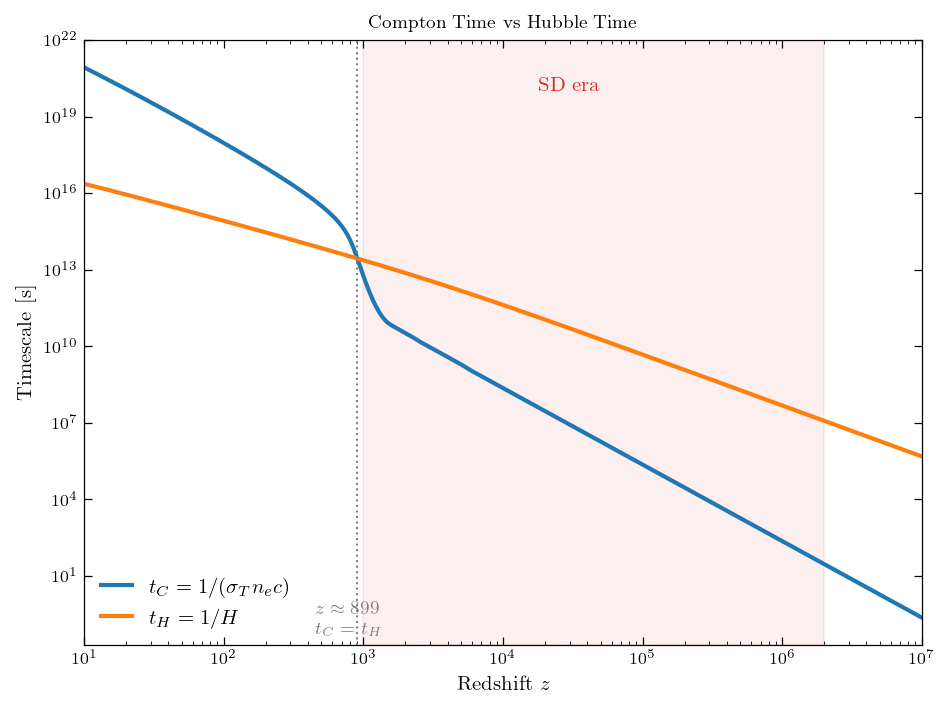

In [6]:
# Compton scattering time: t_C = 1 / (sigma_T n_e c)
t_compton = 1.0 / (_SIGMA_THOMSON * n_e * _C_LIGHT)

# Hubble time: t_H = 1/H
H_arr = np.array([_cosmo_hubble(zi, cosmo) for zi in z])
t_hubble = 1.0 / H_arr

fig, ax = plt.subplots()
ax.loglog(z, t_compton, 'C0-', lw=2, label=r'$t_C = 1/(\sigma_T n_e c)$')
ax.loglog(z, t_hubble, 'C1-', lw=2, label=r'$t_H = 1/H$')

ax.axvspan(1e3, 2e6, alpha=0.07, color='C3')
ax.text(3e4, 1e20, 'SD era', fontsize=10, color='C3', ha='center')

# Compton coupling breaks when t_C ~ t_H
# Find crossing
ratio = t_compton / t_hubble
cross_idx = np.where(np.diff(np.sign(np.log(ratio))))[0]
if len(cross_idx) > 0:
    z_cross = z[cross_idx[0]]
    ax.axvline(z_cross, color='gray', ls=':', lw=1)
    ax.text(z_cross * 0.5, ax.get_ylim()[0] * 3,
            f'$z \\approx {z_cross:.0f}$\n$t_C = t_H$', fontsize=9, color='gray')

ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Timescale [s]')
ax.set_title('Compton Time vs Hubble Time')
ax.set_xlim(10, 1e7)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()